In [ ]:
import tensorflow as tf

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model

In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Dropout, MaxPooling2D

In [ ]:
from tensorflow.keras import layers

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


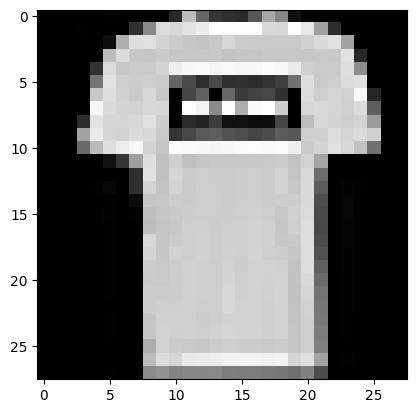

In [ ]:
plt.imshow(x_train[1],cmap="grey")
plt.show()

In [ ]:
x_train_normalised = x_train / 255.0
x_test_normalised = x_test / 255.

In [ ]:
from tensorflow.keras.layers import Conv2D

In [ ]:
model = Sequential([layers.Conv2D(32,(3,3),activation = "relu",input_shape = (28,28,1)),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation = "relu"),
layers.MaxPooling2D(2,2),

layers.Flatten(),
layers.Dense(128,activation = "relu"),
layers.Dense(10,activation = "softmax")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
fashion=model.fit(x_train_normalised,y_train,epochs=6,validation_split=0.2)

Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.8180 - loss: 0.4881 - val_accuracy: 0.8634 - val_loss: 0.3766
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.8807 - loss: 0.3213 - val_accuracy: 0.8741 - val_loss: 0.3289
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.8979 - loss: 0.2786 - val_accuracy: 0.8934 - val_loss: 0.2823
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9081 - loss: 0.2475 - val_accuracy: 0.9008 - val_loss: 0.2683
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9183 - loss: 0.2222 - val_accuracy: 0.9050 - val_loss: 0.2570
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9255 - loss: 0.2005 - val_accuracy: 0.9056 - val_loss: 0.2640


In [ ]:
test_loss,test_acc=model.evaluate(x_test_normalised, y_test)
print ("test_loss = ",test_loss)
print("test_acc = ",test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8992 - loss: 0.2766
test_loss =  0.27656832337379456
test_acc =  0.8992000222206116


In [ ]:
import numpy as np

prediction = model.predict(x_test_normalised[1].reshape(1,28,28,1))
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2


In [ ]:
print(y_test[1])

2
